<a href="https://colab.research.google.com/github/nagasailakshmiMaddala/PRODIGY_DS_04/blob/main/PRODIGY_DS_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import os
import zipfile

# Define the path to the downloaded ZIP file
zip_file_path = '/content/twitter_training.csv.zip'

# Define the directory where the CSV will be extracted
extract_dir = '/content/'

# Extract the CSV file from the zip archive
print(f"Unzipping {zip_file_path}...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Successfully unzipped {zip_file_path} to {extract_dir}")

# Define the path to the extracted CSV file
csv_file_path = os.path.join(extract_dir, 'twitter_training.csv')

# Load the CSV file into a pandas DataFrame, specifying no header and then assigning column names
df = pd.read_csv(csv_file_path, header=None) # Load without header
df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_text'] # Assign correct column names

# Display the first 5 rows of the DataFrame
print('First 5 rows of the DataFrame (with correct headers):')
display(df.head())

Unzipping /content/twitter_training.csv.zip...
Successfully unzipped /content/twitter_training.csv.zip to /content/
First 5 rows of the DataFrame (with correct headers):


,Tweet_ID,Entity,Sentiment,Tweet_text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [27]:
# Initial Data Exploration
print('\nDataFrame Info:')
df.info()

print('\nColumn Names:')
print(df.columns)

print('\nMissing Values:')
print(df.isnull().sum())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Tweet_ID    74682 non-null  int64 
 1   Entity      74682 non-null  object
 2   Sentiment   74682 non-null  object
 3   Tweet_text  73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB

Column Names:
Index(['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_text'], dtype='object')

Missing Values:
Tweet_ID        0
Entity          0
Sentiment       0
Tweet_text    686
dtype: int64


In [28]:
# Data Cleaning: Handle missing values
# Drop rows where 'Tweet_text' is null, as it's essential for sentiment analysis
df.dropna(subset=['Tweet_text'], inplace=True)

print('Missing values after dropping rows with null Tweet_text:')
print(df.isnull().sum())

# Display the distribution of sentiments
print('\nSentiment Distribution:')
print(df['Sentiment'].value_counts())

Missing values after dropping rows with null Tweet_text:
Tweet_ID      0
Entity        0
Sentiment     0
Tweet_text    0
dtype: int64

Sentiment Distribution:
Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


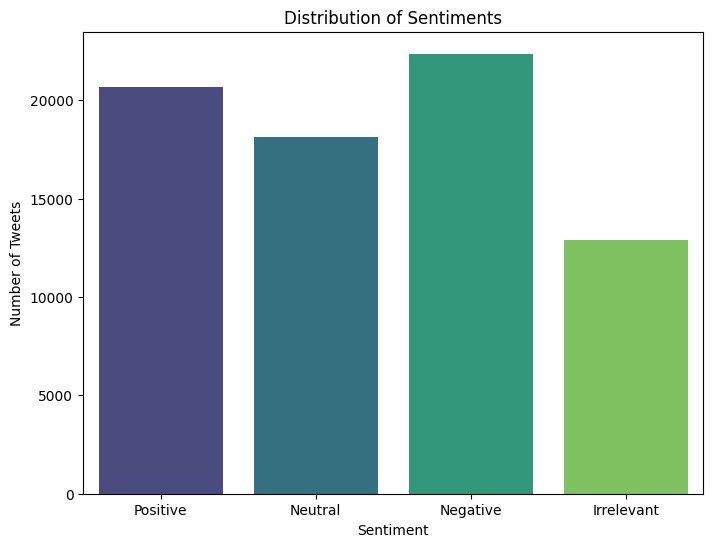

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='viridis', hue='Sentiment', legend=False)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()


Top Entities per Sentiment:

--- Sentiment: Positive ---
Entity
AssassinsCreed               1439
Borderlands                  1017
Cyberpunk2077                 950
PlayStation5(PS5)             936
RedDeadRedemption(RDR)        927
CallOfDutyBlackopsColdWar     856
Hearthstone                   833
Nvidia                        802
Xbox(Xseries)                 785
HomeDepot                     772
Name: count, dtype: int64

--- Sentiment: Neutral ---
Entity
Amazon                    1207
WorldOfCraft              1064
johnson&johnson           1013
ApexLegends                936
Nvidia                     863
Microsoft                  825
LeagueOfLegends            818
Google                     808
RedDeadRedemption(RDR)     807
TomClancysGhostRecon       789
Name: count, dtype: int64

--- Sentiment: Negative ---
Entity
MaddenNFL               1694
NBA2K                   1469
FIFA                    1169
TomClancysRainbowSix    1115
Verizon                 1092
TomClancysGhostRe

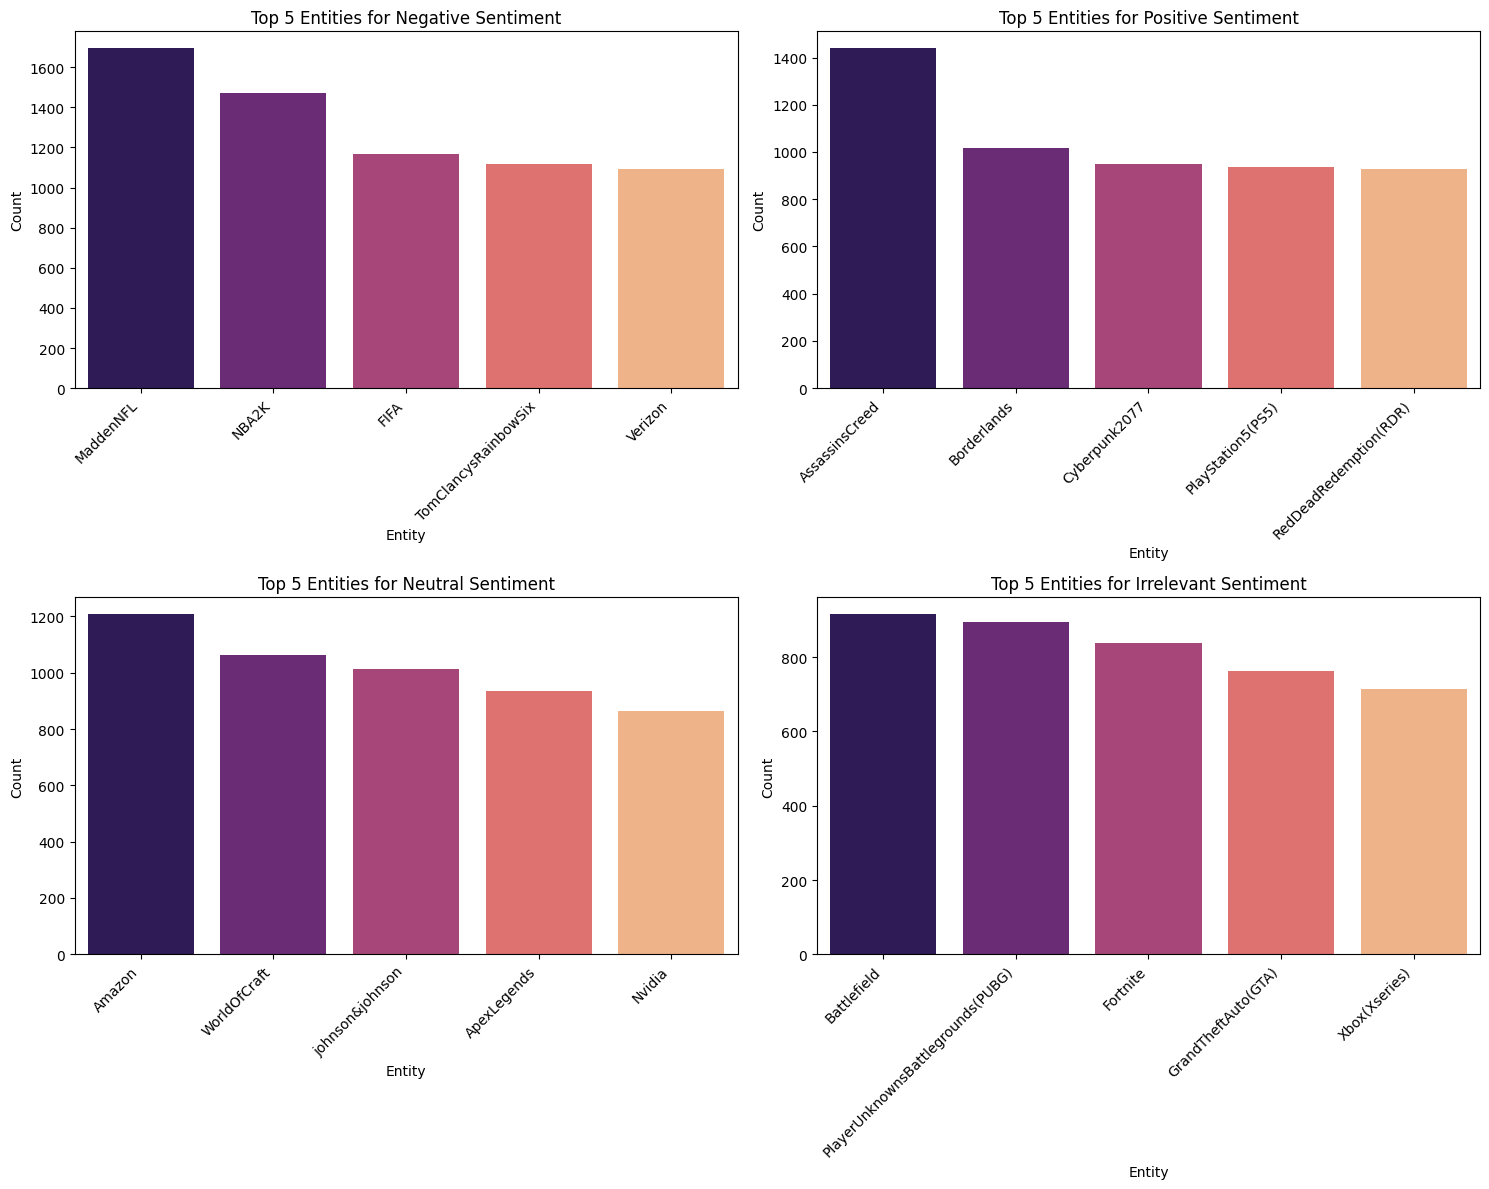

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

print('\nTop Entities per Sentiment:')

for sentiment_label in df['Sentiment'].unique():
    print(f'\n--- Sentiment: {sentiment_label} ---')
    # Filter DataFrame for the current sentiment
    sentiment_df = df[df['Sentiment'] == sentiment_label]
    # Get the value counts for 'Entity' in this sentiment and display top 10
    entity_counts = sentiment_df['Entity'].value_counts().head(10)
    print(entity_counts)

# Visualize the top entities for each sentiment
# Determine the number of unique sentiments to create appropriate subplots
unique_sentiments = df['Sentiment'].nunique()

# Calculate grid size for subplots
rows = (unique_sentiments + 1) // 2
cols = 2 if unique_sentiments > 1 else 1

plt.figure(figsize=(15, 6 * rows)) # Adjust figure size dynamically
sentiment_order = df['Sentiment'].value_counts().index # Order by frequency

for i, sentiment_label in enumerate(sentiment_order):
    sentiment_df = df[df['Sentiment'] == sentiment_label]
    entity_counts = sentiment_df['Entity'].value_counts().head(5)

    plt.subplot(rows, cols, i + 1)
    sns.barplot(x=entity_counts.index, y=entity_counts.values, palette='magma', hue=entity_counts.index, legend=False)
    plt.title(f'Top 5 Entities for {sentiment_label} Sentiment')
    plt.xlabel('Entity')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()